In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import torch
from torch import nn
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from enum import Enum
import pickle

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_device(device)
print(f"{device=}")

device='cuda'


# Clarity goals
- Code U-net
- Stacking input and hidden into single UNet
- Starting hidden state is the board
- Input gets linearly mapped on to the board and then stacked with hidden state
- one-hot encode UNet, input and hidden state

# New goals
- Try out open/ocean == 1, closed/island == 0
- Try out to generate maps of inputs as input for the UNet such that batching is possible and no recurrence is needed

In [2]:
# Observation space
class Tile(Enum):
  OCEAN = 0
  SUBMARINE = 1
  ISLAND = 2
  TRAVELLED = 3

# Action space
class Action(Enum):
  UP = 0
  DOWN = 1
  LEFT = 2
  RIGHT = 3
  NOTHING = 4

In [3]:
board = np.array(
    [
        [0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],
        [0, 0, 2, 0, 0,  0, 2, 0, 0, 0,  0, 0, 2, 2, 0],
        [0, 0, 2, 0, 0,  0, 0, 0, 2, 0,  0, 0, 2, 0, 0],
        [0, 0, 0, 0, 0,  0, 0, 0, 2, 0,  0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],

        [0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],
        [0, 2, 0, 2, 0,  0, 2, 0, 2, 0,  0, 0, 0, 0, 0],
        [0, 2, 0, 2, 0,  0, 2, 0, 0, 0,  0, 0, 0, 0, 0],
        [0, 0, 0, 2, 0,  0, 0, 2, 0, 0,  0, 2, 2, 2, 0],
        [0, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],

        [0, 0, 0, 2, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],
        [0, 0, 2, 0, 0,  0, 0, 2, 0, 0,  0, 2, 0, 0, 0],
        [2, 0, 0, 0, 0,  0, 0, 0, 0, 0,  0, 0, 2, 0, 0],
        [0, 0, 2, 0, 0,  0, 2, 0, 2, 0,  0, 0, 0, 2, 0],
        [0, 0, 0, 2, 0,  0, 0, 0, 0, 0,  0, 0, 0, 0, 0],
    ]
)

board = np.where(board == 2, 0, 1)
print(board)

board_torch = torch.tensor(np.array([[np.eye(len(Tile))[x] for x in row] for row in board]).T).transpose(-2, -1).unsqueeze(0)
board_torch.shape


[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 0 1 1 1 0 1 1 1 1 1 0 0 1]
 [1 1 0 1 1 1 1 1 0 1 1 1 0 1 1]
 [1 1 1 1 1 1 1 1 0 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 0 1 0 1 1 0 1 0 1 1 1 1 1 1]
 [1 0 1 0 1 1 0 1 1 1 1 1 1 1 1]
 [1 1 1 0 1 1 1 0 1 1 1 0 0 0 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 1 0 1 1 1 1 1 1 1 1 1 1 1]
 [1 1 0 1 1 1 1 0 1 1 1 0 1 1 1]
 [0 1 1 1 1 1 1 1 1 1 1 1 0 1 1]
 [1 1 0 1 1 1 0 1 0 1 1 1 1 0 1]
 [1 1 1 0 1 1 1 1 1 1 1 1 1 1 1]]


torch.Size([1, 4, 15, 15])

In [4]:
class GameField(Dataset):
    def __init__(self, sequences_movement, final_positions, board, paths, device):
        # List of strings to list of list of numbers
        self.sequences = [[int(number_string) for number_string in string.strip().split(" ")] for string in sequences_movement]
        self.final_positions = torch.tensor(np.array(final_positions))
        self.board = torch.tensor(board).unsqueeze(0)
        self.paths = paths

    def __len__(self):
        return self.final_positions.size()[0]

    def __getitem__(self, index):
        return self.sequences[index], self.final_positions[index], self.board, self.paths[index]

In [6]:
with open("intermediate_sequences.pkl", 'rb') as file:
  intermediate_sequences = pickle.load(file)
with open("intermediate_paths.pkl", 'rb') as file:
  intermediate_paths = pickle.load(file)

In [7]:
intermediate_sequences = [s.strip() for s in intermediate_sequences]
final_positions = [path[-1][0] * 15 + path[-1][1] for path in intermediate_paths]
inputs = intermediate_sequences

random_seed = 42

train_inputs, test_inputs, train_labels, test_labels = train_test_split(
    inputs, final_positions, test_size=0.2, random_state=random_seed, shuffle=False
)

train_data = GameField(train_inputs, train_labels, board, intermediate_paths, device)
test_data = GameField(test_inputs, test_labels, board, intermediate_paths, device)

In [8]:
class RNNUNet(nn.Module):
    def __init__(self, num_channels, grid_size=15, num_tiles = len(Tile), num_directions= len(Action), bias=False):
        super().__init__()

        self.grid_size = grid_size
        self.num_directions = num_directions
        self.direction_to_flattened_matrix = nn.Sequential(
            nn.Linear(num_directions, 32, bias=bias),
            nn.ReLU(),
            nn.Linear(32, 64, bias=bias),
            nn.ReLU(),
            nn.Linear(64, grid_size**2, bias=bias),
            nn.ReLU(),
        )

        self.UPSAMPLE = nn.Upsample(scale_factor=2)
        self.DOWNSAMPLE = nn.MaxPool2d(2, 2)
        self.INPUT = nn.Sequential(
            # One-Hot encoded board plus the 1 channel from direction
            nn.Conv2d(3, num_channels, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels,  num_channels, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels,  num_channels, kernel_size=3, padding=1, stride=1, bias=bias),
        )
        self.DOWN1 = nn.Sequential(
            nn.Conv2d(num_channels,     num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2, num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2, num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
        )
        self.BOTTOM = nn.Sequential(
            nn.Conv2d(num_channels * 2, num_channels * 4, kernel_size=3, padding=1, stride=1, bias=bias, groups=4),
            nn.ReLU(),
            nn.Conv2d(num_channels * 4, num_channels * 4, kernel_size=3, padding=1, stride=1, bias=bias, groups=4),
            nn.ReLU(),
            nn.Conv2d(num_channels * 4, num_channels * 4, kernel_size=3, padding=1, stride=1, bias=bias, groups=4),
        )
        self.UP1 = nn.Sequential(
            nn.Conv2d(num_channels * 2 + num_channels * 4 , num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2                    , num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2                    , num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
        )
        self.OUTPUT = nn.Sequential(
            nn.Conv2d(num_channels * 1 + num_channels * 2 , num_channels * 1, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels * 1                    , num_channels * 1, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels * 1                    , 1               , kernel_size=3, padding=1, stride=1, bias=bias),
            nn.BatchNorm2d(1),
            nn.ReLU()
        )
        self.HIDDEN = nn.Sequential(
            nn.Conv2d(num_channels * 1 + num_channels * 2 , num_channels * 1, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels * 1                    , num_channels * 1, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels * 1                    , 1       , kernel_size=3, padding=1, stride=1, bias=bias),
            nn.BatchNorm2d(1),
            nn.ReLU()
        )
        self.softmax = nn.LogSoftmax(dim=1)
        self.relu = nn.ReLU()

    def one_hot_encode_direction(self, direction):
        one_hot = np.eye(self.num_directions)[direction]
        input_tensor = torch.tensor(one_hot).float()
        return input_tensor

    def forward(self, direction, hidden, board):
        # Make hidden float32
        if hidden.dtype != torch.float32:
          hidden = hidden.float()

        # One-Hot encode [North, South, West, East, Nothing] to (1, 0, 0, 0, 0), (0, 1, 0, 0, 0) and etc.
        x = self.one_hot_encode_direction(direction)
        # Aggravate data over (15, 15) board
        X_flattened = self.direction_to_flattened_matrix(x)
        X = X_flattened.reshape(-1, 1, self.grid_size, self.grid_size)
        # Add zeroes to bottom and right to make it even matrix such that downsample steps have (8, 8) and (4, 4)
        # Goes from (batch_size, 1, 15, 15) to (batch_size, 1, 16, 16)
        X_padded = F.pad(X, (0, 1, 0, 1))
        # Goes from (batch_size, 5, 15, 15) to (batch_size, 15, 16, 16)
        hidden_padded = F.pad(hidden, (0, 1, 0, 1))
        board_padded = F.pad(board, (0, 1, 0, 1))

        # Stack X_padded and hidden_padded
        stacked = torch.hstack((X_padded, hidden_padded, board_padded)).float()
        Layer1Encoder = self.INPUT(stacked)
        Layer1EncoderDownsample = self.DOWNSAMPLE(Layer1Encoder)
        Layer2Encoder = self.DOWN1(Layer1EncoderDownsample)
        Layer2EncoderDownsample = self.DOWNSAMPLE(Layer2Encoder)
        BOTTLENECK = self.BOTTOM(Layer2EncoderDownsample)

        BOTTLENECKUpsample = self.UPSAMPLE(BOTTLENECK)
        stacked = torch.hstack((Layer2Encoder, BOTTLENECKUpsample))
        Layer2Decoder = self.UP1(stacked)

        Layer2DecoderUpsample = self.UPSAMPLE(Layer2Decoder)
        stacked = torch.hstack((Layer1Encoder, Layer2DecoderUpsample))
        i2h_padded = self.HIDDEN(stacked)
        i2o_padded = self.OUTPUT(stacked)

        i2h = i2h_padded[:, :, :15, :15]
        i2o = i2o_padded[:, :, :15, :15]
        # i2o = self.softmax(i2o)

        return i2o, i2h

In [9]:
def train_model(
    train_data,
    test_data,
    # Expected shape is (1, len(Tile), 15, 15)
    board_torch,
    model,
    loss_fn,
    epochs=10,
    lr=0.01,
    print_every=1,
    visualize_every=100,
):
    loss_dict = {"train": [], "test": []}

    # We use a `DataLoader` to get batching for free!
    train_data_loader = DataLoader(train_data, batch_size=1, shuffle=True, generator=torch.Generator(device=device))
    test_data_loader = DataLoader(test_data, batch_size=1, shuffle=True, generator=torch.Generator(device=device))
    optimizer = Adam(model.parameters(), lr=lr)

    # Print header.
    print(f"Epoch    Train RMSRE      Test RMSRE")

    for epoch in range(epochs):
        model.train()
        epoch_loss_sum = 0
        count = 0

        for sequence, final_position, board, path in train_data_loader:
            count += 1
            print(f"{count} of {len(train_data)}")

            # Reset optimizer gradients.
            optimizer.zero_grad()

            hidden = torch.zeros((1, 1, 15, 15))
            for movement in sequence:
              # Predict the output
              output, hidden = model(movement, hidden, board)

            if (count + 1) % visualize_every == 0:
              fig, ax = plt.subplots(1, 1, figsize = (8, 8))
              ax.imshow(output.cpu().detach().numpy().squeeze().reshape(15, 15))

              length_path = len(path)
              for index, pos in enumerate(path):
                pos = pos.cpu().detach().flatten()
                y, x = pos[0], pos[1]
                circle = Circle((x, y), 0.2, fill=True, color="red", alpha=(index+1) / length_path)
                ax.add_patch(circle)

              ax.add_patch(circle)
              plt.show()

            # Compute the loss
            loss = loss_fn(output.flatten().unsqueeze(0), final_position)
            epoch_loss_sum += loss.item()

            # Compute gradients according to newly computed loss.
            loss.backward()

            # Update the model parameters.
            optimizer.step()

        # loss_dict["train"].append(epoch_loss_sum / len(train_data_loader))

        # with torch.no_grad():
        #     model.eval()

        #     test_pred = model(test_data.input, test_data.params) * test_data.input
        #     train_pred = model(train_data.input, train_data.params) * train_data.input
        #     test_loss = loss_fn(test_pred, test_data.labels)
        #     loss_dict["test"].append(test_loss.item())

        #     if (epoch + 1) % print_every == 0:
        #         print(
        #             f"{epoch+1: <7}  {loss_fn(train_pred, train_data.labels).item(): <12.6e}  {loss_fn(test_pred, test_data.labels).item(): .6e}"
        #         )

    model.eval()
    return model, loss_dict

def plot_losses(train, test):
    plt.semilogy(train, label="train", marker=".", lw=2)
    plt.semilogy(test, label="test", marker=".", lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("RMSRE")
    plt.legend()
    plt.show()

In [10]:
# trained_RNN, loss_dict = train_model(
#     train_data = train_data,
#     test_data = test_data,
#     # Expected shape is (1, len(Tile), 15, 15)
#     board_torch = board_torch,
#     model = RNNUNet(32, bias=False),
#     loss_fn = nn.NLLLoss(),
#     epochs=10,
#     lr=1e-3,
#     print_every=1,
#     visualize_every=25,
# )

# Input the sequence mapped to a 15, 15 grid

In [367]:
from cv2.gapi import mask


def mask_to_filter(filter, grid_size=15):
    filter = filter[torch.abs(filter.sum(dim=1)) != 0]
    filter = filter.T[torch.abs(filter.sum(dim=0)) != 0].T
    indices = torch.where(filter == 2)
    sub_pos = list(zip(indices[0].cpu(), indices[1].cpu()))[0]
    x, y = sub_pos
    return filter, (x * grid_size + y).item()

def determenistic_sub_finding(mask):
    filter, sub_pos = mask_to_filter(mask)

    x_shape, y_shape = filter.shape
    X_shape, Y_shape = board.shape
    x_out, y_out = X_shape - x_shape + 1, Y_shape - y_shape + 1

    big_matrix = torch.tensor(board).view(1, 1, X_shape, Y_shape).float()
    filter = filter.view(1, 1, x_shape, y_shape).float()

    output = F.conv2d(big_matrix, filter, stride=1, padding=0)

    output = torch.where(output == filter.sum(), 1, 0) 
    output = output / output.sum()

    flattened_output = output.flatten()
    flat_matrix = torch.zeros((X_shape * Y_shape))
    for position in range(x_out * y_out):
        value = flattened_output[position]
        if value > 0:
            x_smaller, y_smaller = position // y_out, position % y_out
            adjusted_position = x_smaller * 15 + y_smaller
            flat_matrix[adjusted_position + sub_pos] = value

    matrix = flat_matrix.view(X_shape, Y_shape)
    return matrix

def path_to_mask(paths):
    paths_masked = np.zeros((len(paths), 15, 15))
    for index, path in enumerate(paths):
        for i, pos in enumerate(path):
            x, y = pos[0], pos[1]
            if i == len(path) - 1:
                paths_masked[index, x, y] = 2
            else:
                paths_masked[index, x, y] = 1


    return paths_masked

def standardize_masks(masks):
    paths_masked_standardized = masks.copy()
    for i in range(masks.shape[0]):
    #     matrix = masks[i]
    #     rows, cols = np.where(matrix == 1)

    #     if len(rows) > 0 and len(cols) > 0:
    #         min_row, min_col = np.min(rows), np.min(cols)
    #         shifted = matrix[min_row:, min_col:]
    #         pad_rows = 15 - shifted.shape[0]
    #         pad_cols = 15 - shifted.shape[1]
    #         shifted_padded = np.pad(
    #             shifted,
    #             ((0, pad_rows), (0, pad_cols)),
    #             mode='constant',
    #             constant_values=0
    #         )
    #     else:
    #         shifted_padded = matrix
    #     paths_masked_standardized[i] = shifted_padded
    # return paths_masked_standardized

        mask = paths_masked_standardized[i]

        filter, sub_pos = mask_to_filter(torch.tensor(mask))
        filter = filter.cpu().numpy()
        pad_rows = 15 - filter.shape[0]
        pad_cols = 15 - filter.shape[1]
        padded = np.pad(
            filter,
            pad_width=((0, pad_rows), (0, pad_cols)),
            mode='constant',
            constant_values=0
        )
        paths_masked_standardized[i] = padded
    return paths_masked_standardized

In [368]:
class SequenceMapped(Dataset):
    def __init__(self, mapped_paths, final_positions, board, device):
        # List of strings to list of list of numbers
        self.mapped_paths = torch.tensor(mapped_paths).unsqueeze(1).float()
        self.final_positions = torch.tensor(np.array(final_positions)).unsqueeze(1).long()
        self.board = torch.tensor(board).float().unsqueeze(0).repeat(self.mapped_paths.shape[0], 1, 1).unsqueeze(1)

    def __len__(self):
        return self.final_positions.size()[0]

    def __getitem__(self, index):
        return self.mapped_paths[index], self.final_positions[index], self.board[index]

class SequenceMappedTest(SequenceMapped):
    def __init__(self, mapped_paths, final_positions, board, paths, device):
        # List of strings to list of list of numbers
        super().__init__(mapped_paths, final_positions, board, device)
        self.paths = paths

    def __getitem__(self, index):
        return self.mapped_paths[index], self.final_positions[index], self.board[index], self.paths[index]

In [369]:
random_seed = 42

masks = path_to_mask(intermediate_paths)
paths_mapped_standardized = standardize_masks(masks)

train_inputs, test_inputs, train_labels, test_labels = train_test_split(
    paths_mapped_standardized, final_positions, test_size=0.2, random_state=random_seed, shuffle=False
)
_, _, train_paths, test_paths = train_test_split(
    paths_mapped_standardized, intermediate_paths, test_size=0.2, random_state=random_seed, shuffle=False
)

train_data = SequenceMapped(train_inputs, train_labels, board, device)
test_data = SequenceMappedTest(test_inputs, test_labels, board, test_paths, device)

In [371]:
class UNet(nn.Module):
    def __init__(self, num_channels, grid_size=15, num_tiles = len(Tile), num_directions= len(Action), bias=False):
        super().__init__()

        self.grid_size = grid_size
        self.num_directions = num_directions

        self.UPSAMPLE = nn.Upsample(scale_factor=2)
        self.DOWNSAMPLE = nn.MaxPool2d(2, 2)
        self.INPUT = nn.Sequential(
            # One-Hot encoded board plus the 1 channel from direction
            nn.Conv2d(2, num_channels, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels,  num_channels, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels,  num_channels, kernel_size=3, padding=1, stride=1, bias=bias),
        )
        self.DOWN1 = nn.Sequential(
            nn.Conv2d(num_channels,     num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2, num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2, num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
        )
        self.BOTTOM = nn.Sequential(
            nn.Conv2d(num_channels * 2, num_channels * 4, kernel_size=3, padding=1, stride=1, bias=bias, groups=4),
            nn.ReLU(),
            nn.Conv2d(num_channels * 4, num_channels * 4, kernel_size=3, padding=1, stride=1, bias=bias, groups=4),
            nn.ReLU(),
            nn.Conv2d(num_channels * 4, num_channels * 4, kernel_size=3, padding=1, stride=1, bias=bias, groups=4),
        )
        self.UP1 = nn.Sequential(
            nn.Conv2d(num_channels * 2 + num_channels * 4 , num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2                    , num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
            nn.ReLU(),
            nn.Conv2d(num_channels * 2                    , num_channels * 2, kernel_size=3, padding=1, stride=1, bias=bias, groups=2),
        )
        self.OUTPUT = nn.Sequential(
            nn.Conv2d(num_channels * 1 + num_channels * 2 , num_channels * 1, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels * 1                    , num_channels * 1, kernel_size=3, padding=1, stride=1, bias=bias),
            nn.ReLU(),
            nn.Conv2d(num_channels * 1                    , 1               , kernel_size=3, padding=1, stride=1, bias=bias),
            nn.BatchNorm2d(1),
            nn.ReLU()
        )
        self.softmax = nn.LogSoftmax(dim=1)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

    def forward(self, mapping, hidden):
        hidden_padded = F.pad(hidden, (0, 1, 0, 1))
        mapping_padded = F.pad(mapping, (0, 1, 0, 1))

        # Stack X_padded and hidden_padded
        stacked = torch.hstack((hidden_padded, mapping_padded)).float()
        Layer1Encoder = self.INPUT(stacked)
        Layer1EncoderDownsample = self.DOWNSAMPLE(Layer1Encoder)
        Layer2Encoder = self.DOWN1(Layer1EncoderDownsample)
        Layer2EncoderDownsample = self.DOWNSAMPLE(Layer2Encoder)
        BOTTLENECK = self.BOTTOM(Layer2EncoderDownsample)

        BOTTLENECKUpsample = self.UPSAMPLE(BOTTLENECK)
        stacked = torch.hstack((Layer2Encoder, BOTTLENECKUpsample))
        Layer2Decoder = self.UP1(stacked)

        Layer2DecoderUpsample = self.UPSAMPLE(Layer2Decoder)
        stacked = torch.hstack((Layer1Encoder, Layer2DecoderUpsample))
        i2o_padded = self.OUTPUT(stacked)

        i2o = i2o_padded[:, :, :15, :15]
        i2o = i2o * hidden
        # i2o = self.softmax(i2o)
        i2o = self.flatten(i2o)

        return i2o

In [ ]:
def train_model(
    train_data,
    test_data,
    # Expected shape is (1, len(Tile), 15, 15)
    board_torch,
    model,
    loss_fn,
    epochs=10,
    lr=0.01,
    print_every=1,
    visualize_images=100,
    batch_size=32
):
    loss_dict = {"train": [], "test": []}

    # We use a `DataLoader` to get batching for free!
    train_data_loader = DataLoader(train_data, batch_size=32, shuffle=True, generator=torch.Generator(device=device))
    test_data_loader = DataLoader(test_data, batch_size=1, shuffle=True, generator=torch.Generator(device=device))
    optimizer = Adam(model.parameters(), lr=lr)

    # Print header.
    print(f"Epoch    Train RMSRE      Test RMSRE")

    for epoch in range(epochs):
        model.train()
        epoch_loss_sum = 0
        count = 0

        for mapped_path, final_position, board in train_data_loader:
            count += 1
            # print(f"{count * batch_size} of {len(train_data)}")

            # Reset optimizer gradients.
            optimizer.zero_grad()
            output = model(mapped_path, board)

            # Compute the loss
            loss = loss_fn(output, final_position.squeeze(1))
            epoch_loss_sum += loss.item()

            # Compute gradients according to newly computed loss.
            loss.backward()

            # Update the model parameters.
            optimizer.step()

        loss_dict["train"].append(epoch_loss_sum / len(train_data_loader))

        with torch.no_grad():
            model.eval()

            vis_count = 0
            for masked_path, final_position, board, path in test_data_loader:
              output = model(masked_path, board)

              fig, ax = plt.subplots(1, 2, figsize = (8, 8))
              ax[0].imshow(output.cpu().detach().numpy().squeeze().reshape(15, 15))
              deterministic_output = determenistic_sub_finding(masked_path.squeeze())
              ax[1].imshow(deterministic_output.cpu().squeeze())

              length_path = len(path)
              for index, pos in enumerate(path):
                pos = pos.cpu().detach().flatten()
                y, x = pos[0], pos[1]
                circle = Circle((x, y), 0.2, fill=True, color="red", alpha=((index+1) / length_path) ** 2)
                ax[0].add_patch(circle)
                circle = Circle((x, y), 0.2, fill=True, color="red", alpha=((index+1) / length_path) ** 2)
                ax[1].add_patch(circle)

              x = final_position[0].cpu() % 15
              y = final_position[0].cpu() // 15
              circle = Circle((x, y), 0.2, fill=True, color="black", alpha=1)
              ax[0].add_patch(circle)

              plt.show()

              if vis_count > visualize_images:
                break;
              else:
                vis_count += 1


            test_pred = model(test_data.mapped_paths, test_data.board)
            train_pred = model(train_data.mapped_paths, train_data.board)
            test_loss = loss_fn(test_pred, test_data.final_positions.squeeze(1))
            loss_dict["test"].append(test_loss.item())

            if (epoch + 1) % print_every == 0:
                print(
                    f"{epoch+1: <7}  {loss_fn(train_pred, train_data.final_positions.squeeze(1)).item(): <12.6e}  {loss_fn(test_pred, test_data.final_positions.squeeze(1)).item(): .6e}"
                )

    model.eval()
    return model, loss_dict

def plot_losses(train, test):
    plt.semilogy(train, label="train", marker=".", lw=2)
    plt.semilogy(test, label="test", marker=".", lw=2)
    plt.xlabel("Epoch")
    plt.ylabel("RMSRE")
    plt.legend()
    plt.show()

Epoch    Train RMSRE      Test RMSRE


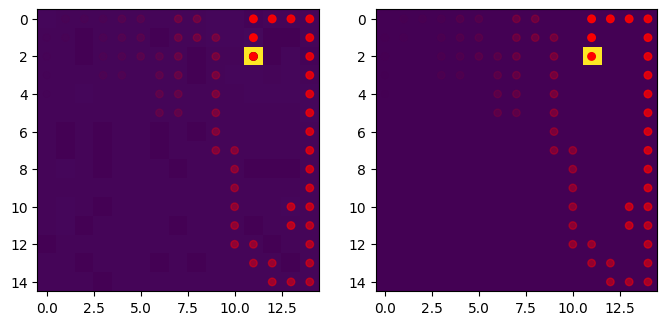

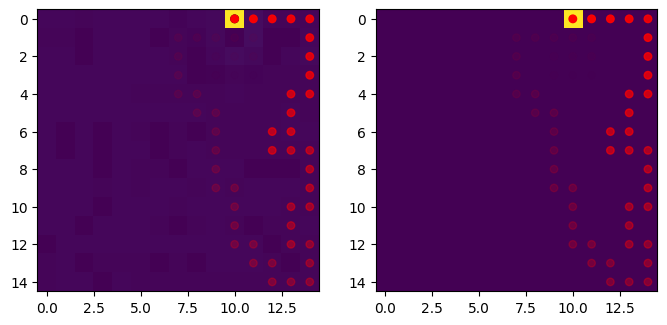

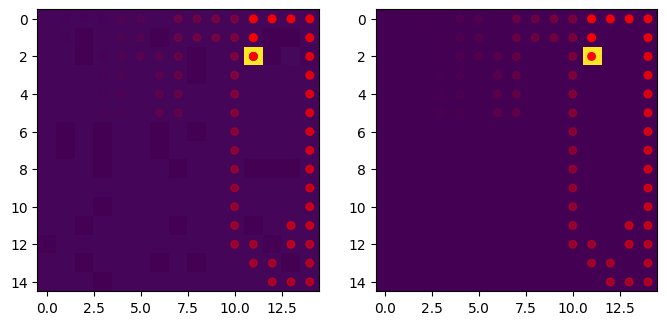

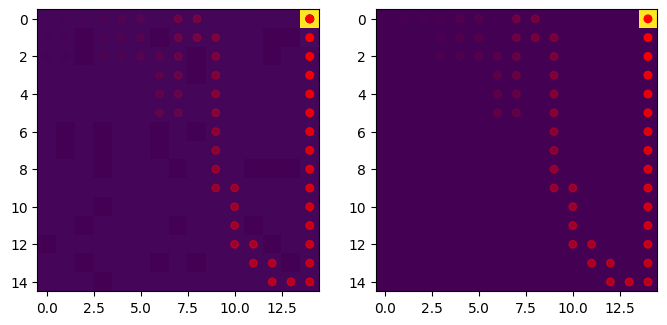

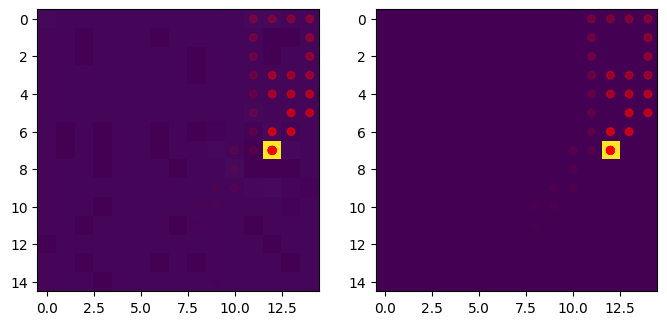

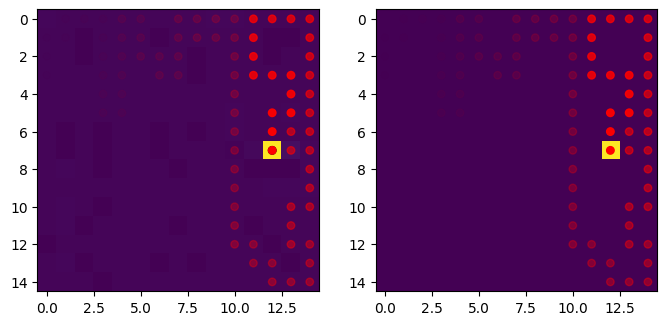

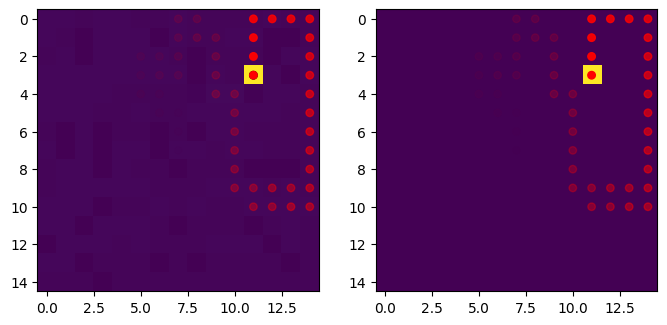

1        -2.524913e+01  -2.524780e+01


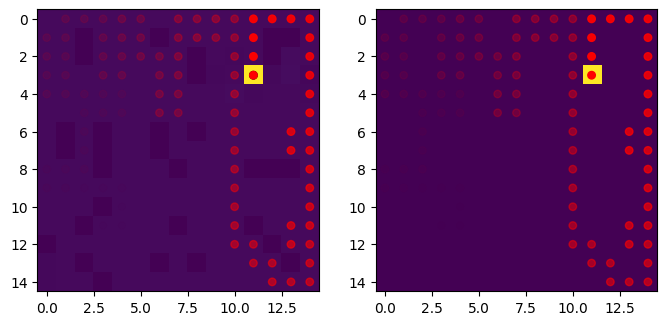

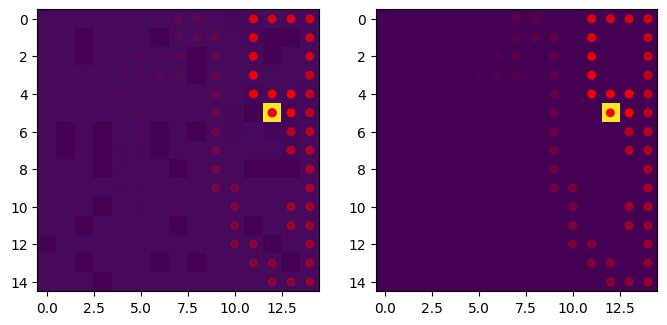

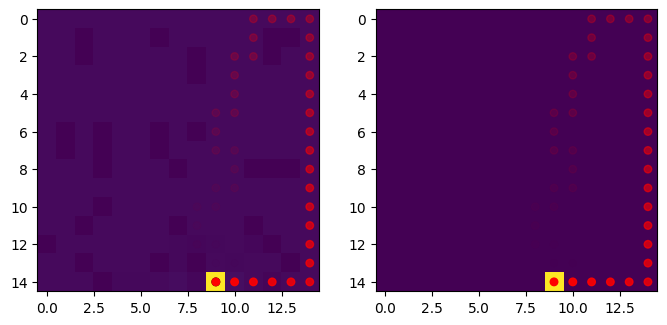

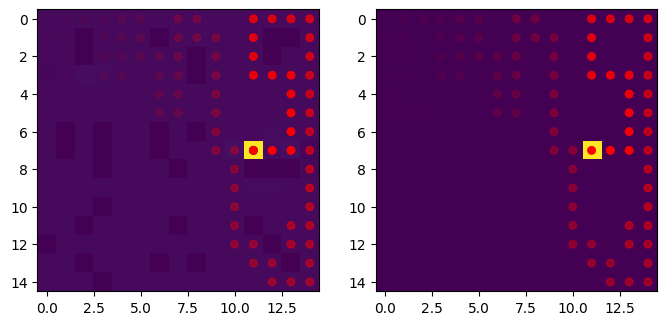

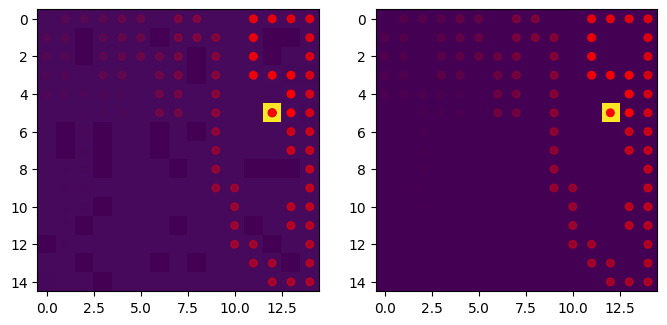

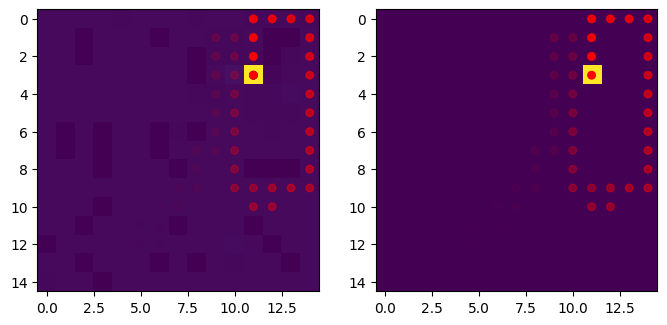

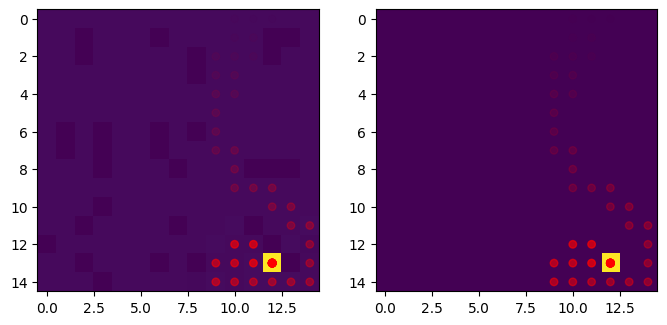

2        -3.425046e+01  -3.424908e+01


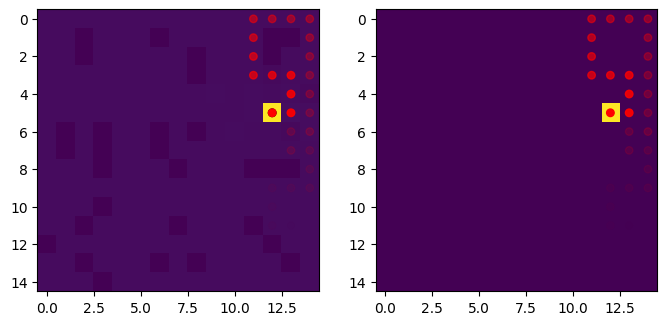

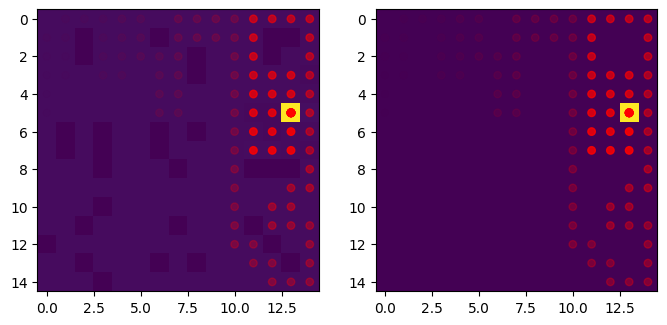

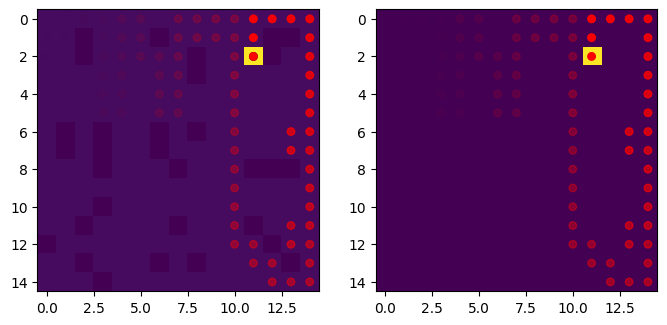

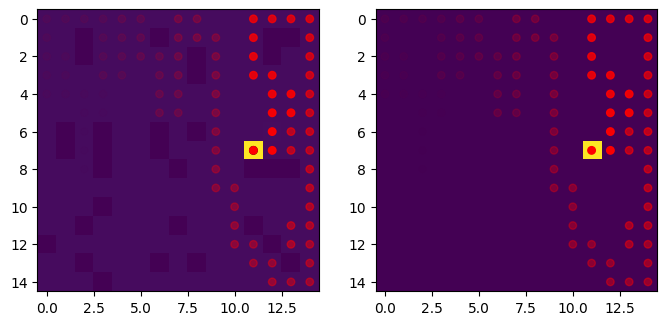

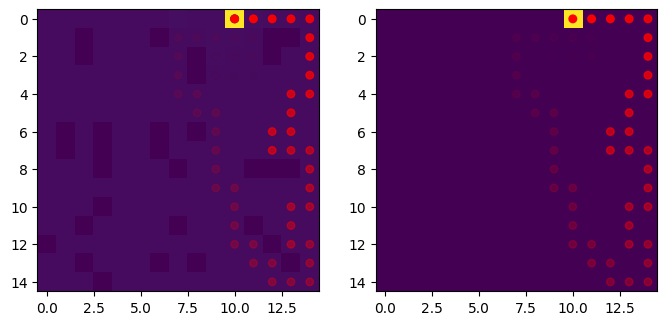

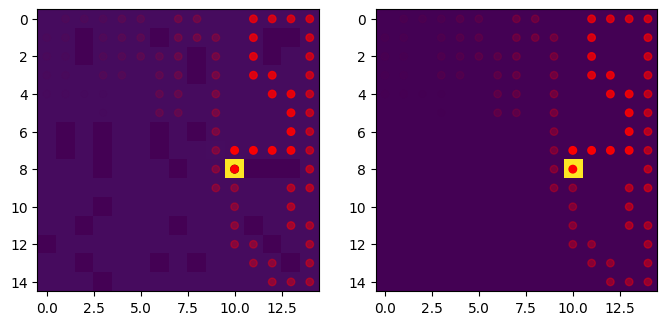

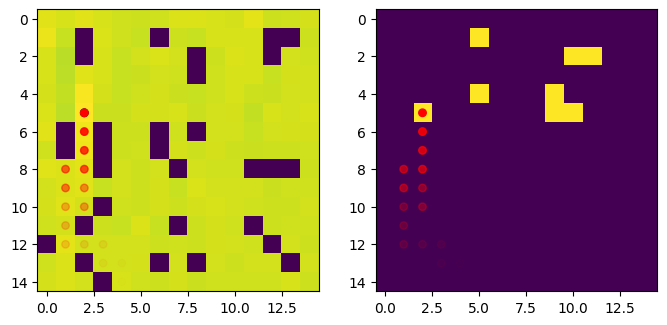

3        -4.313492e+01  -4.313244e+01


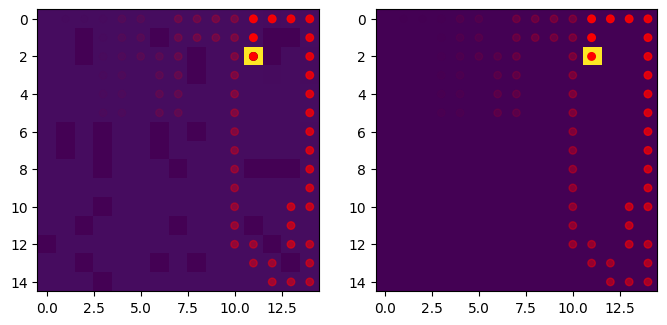

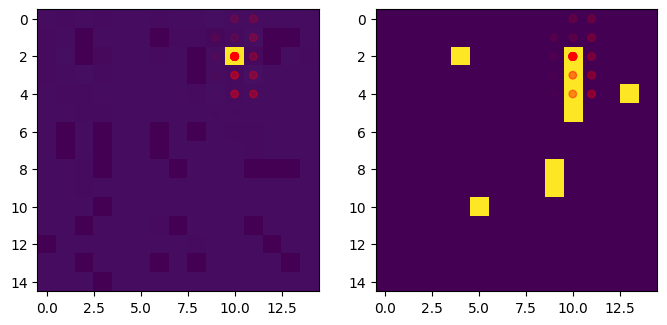

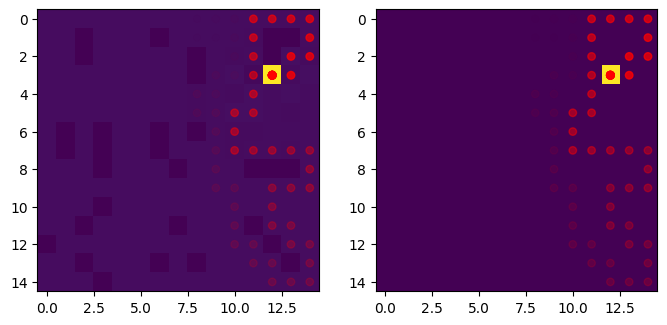

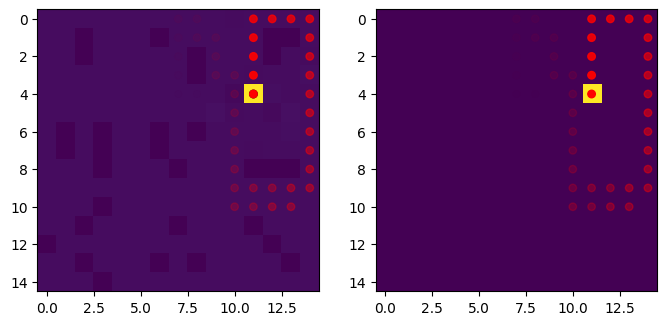

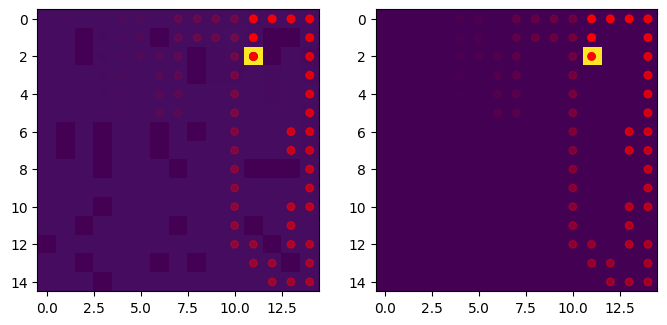

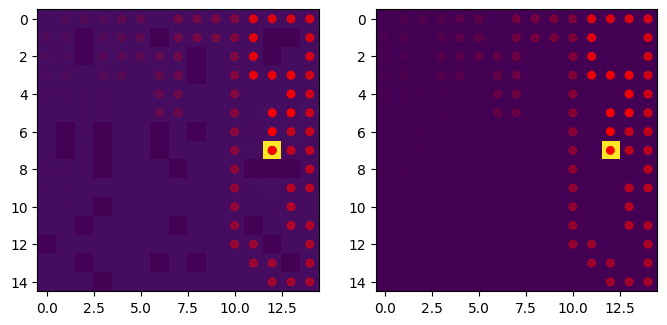

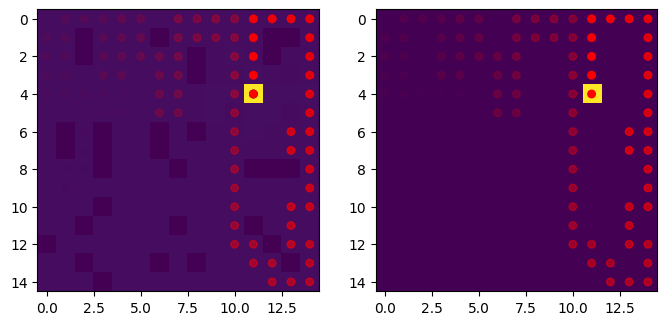

4        -5.180922e+01  -5.180516e+01


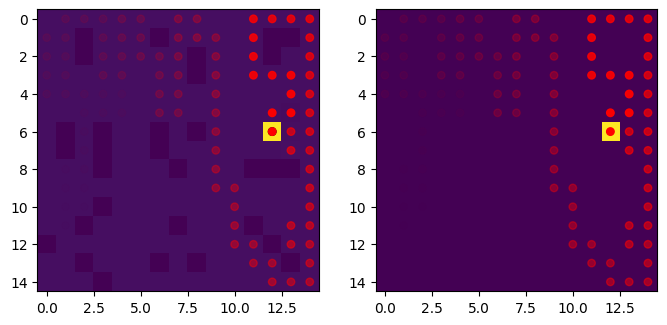

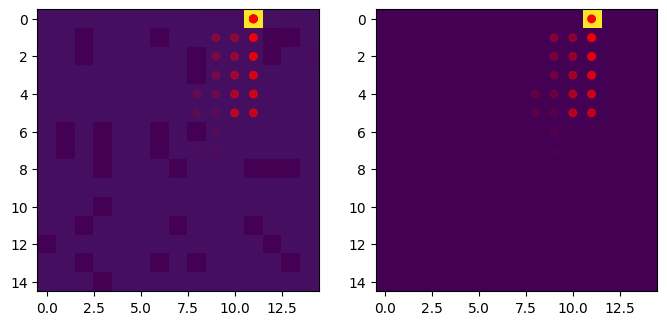

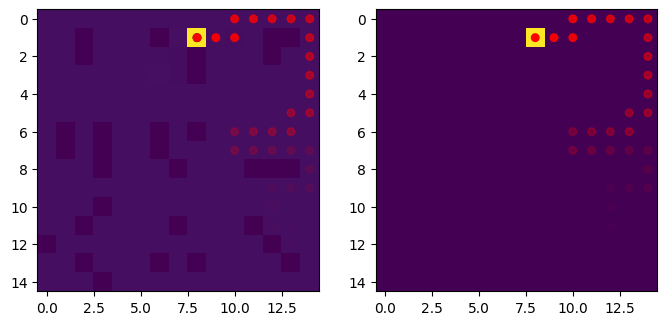

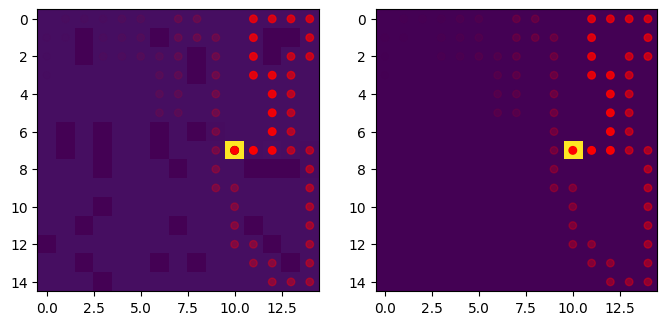

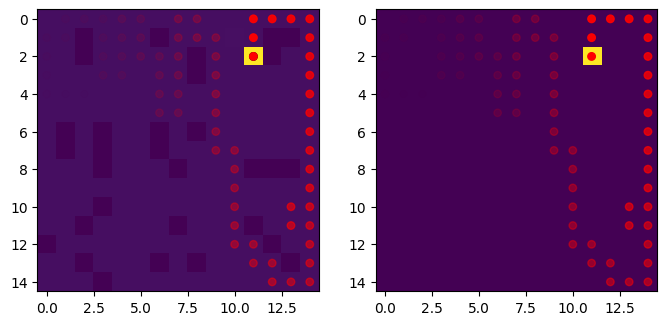

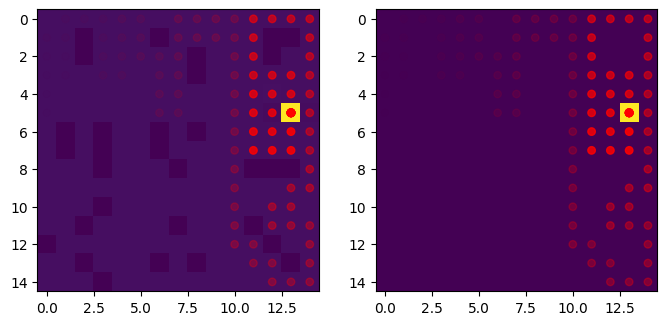

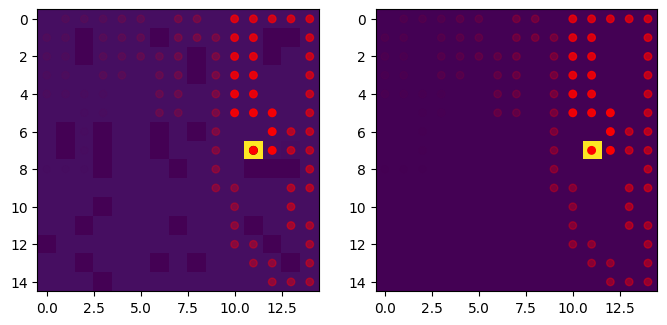

5        -6.009651e+01  -6.009660e+01


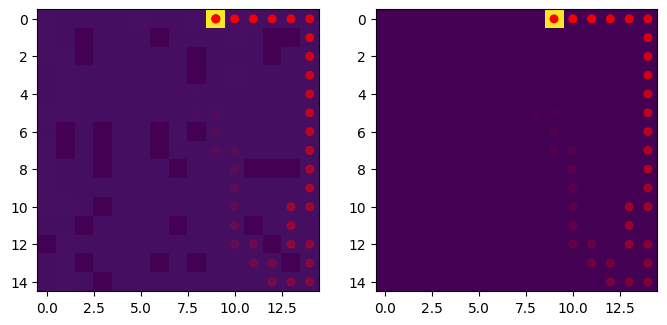

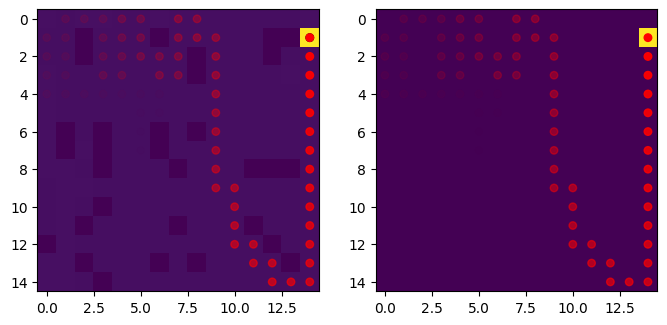

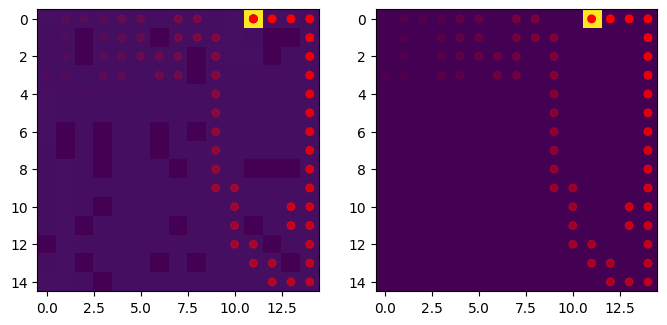

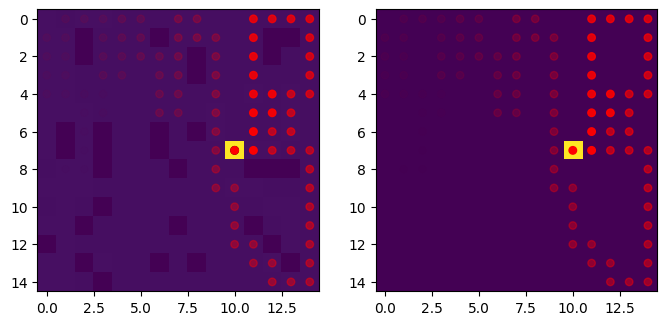

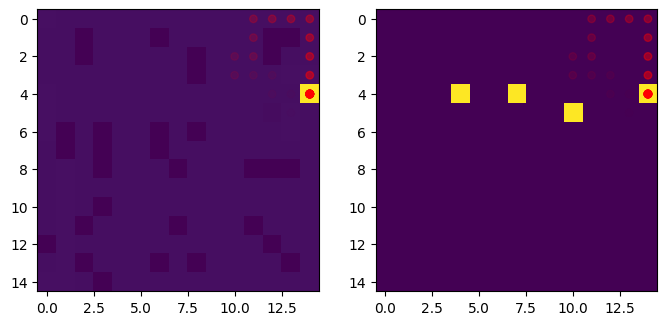

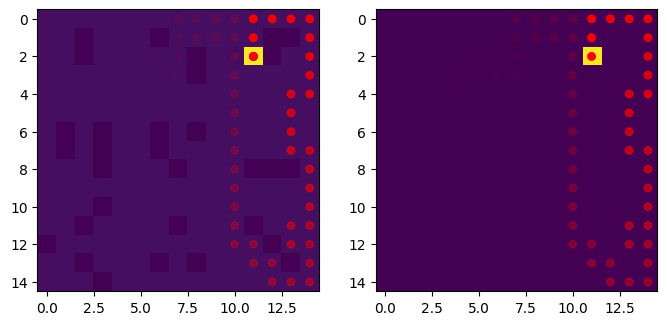

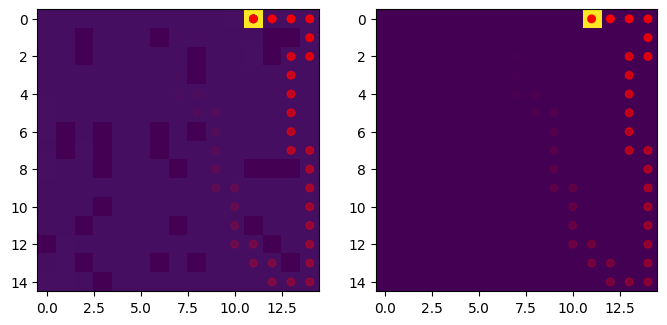

6        -6.848557e+01  -6.848595e+01


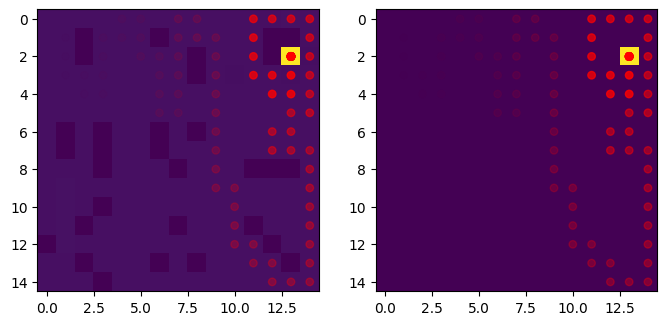

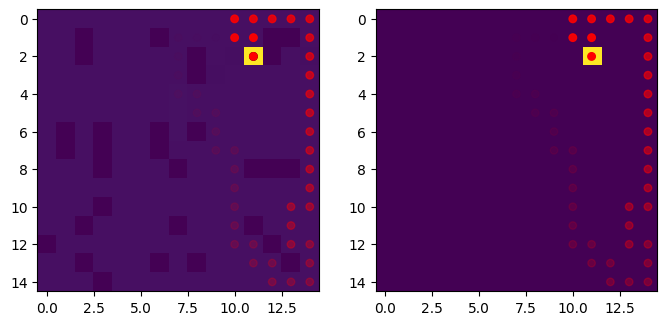

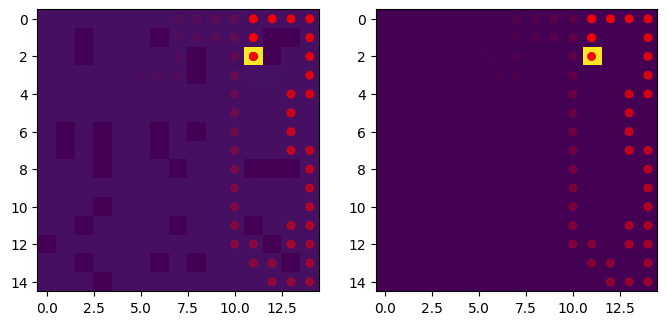

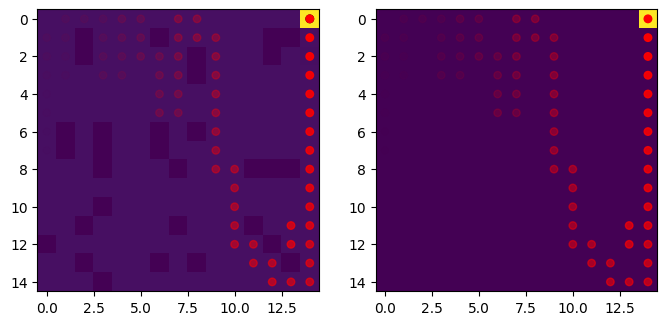

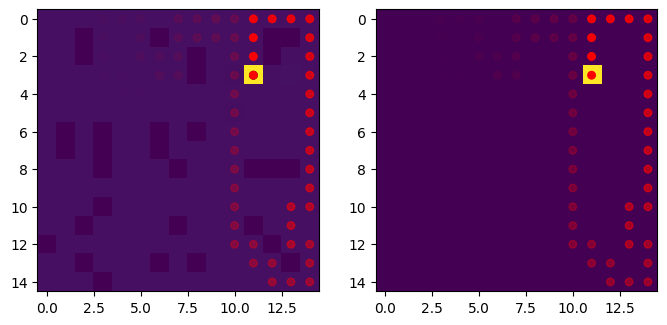

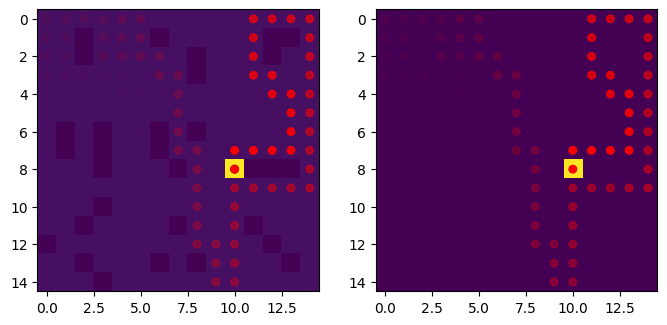

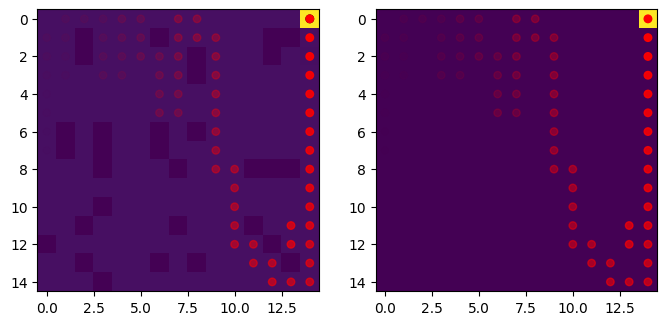

7        -7.660191e+01  -7.660074e+01


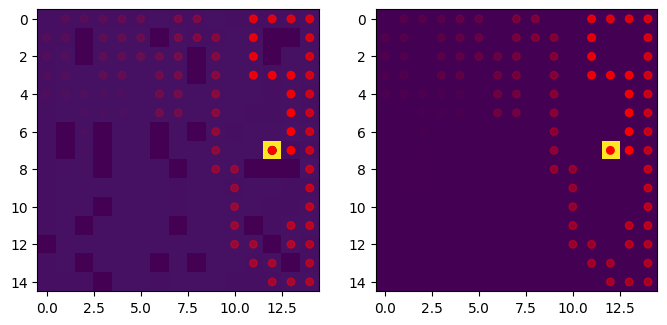

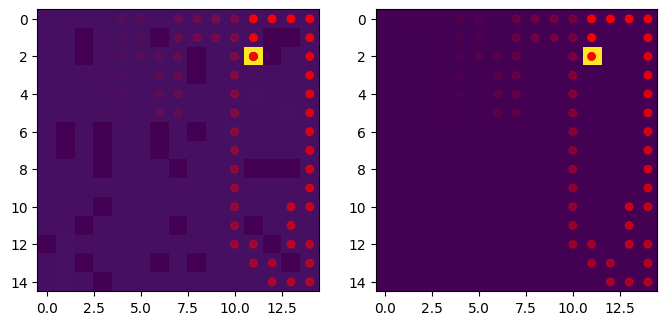

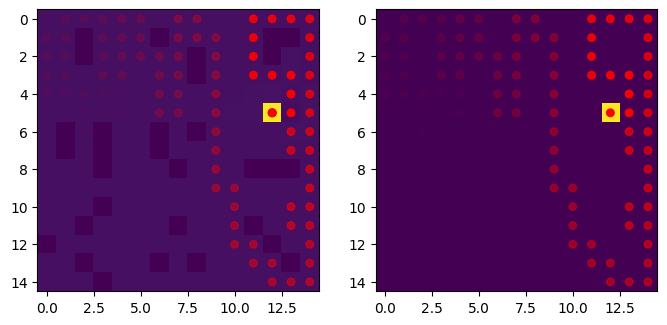

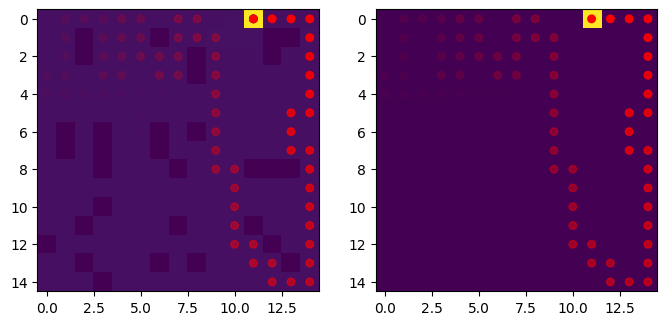

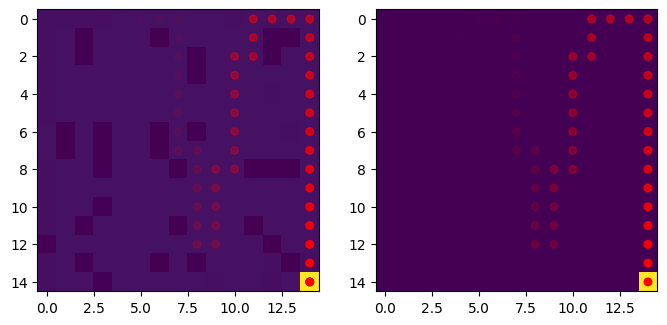

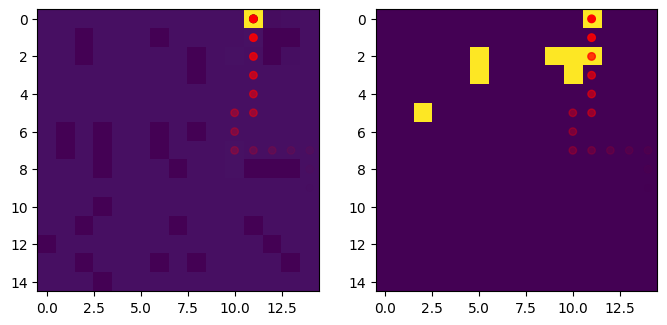

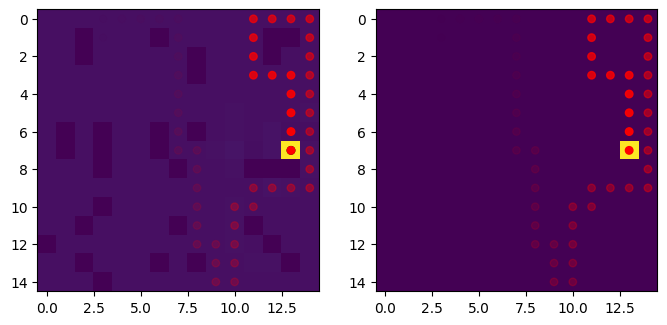

8        -8.524132e+01  -8.524297e+01


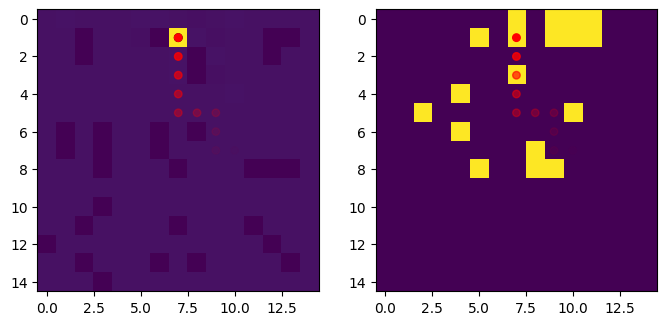

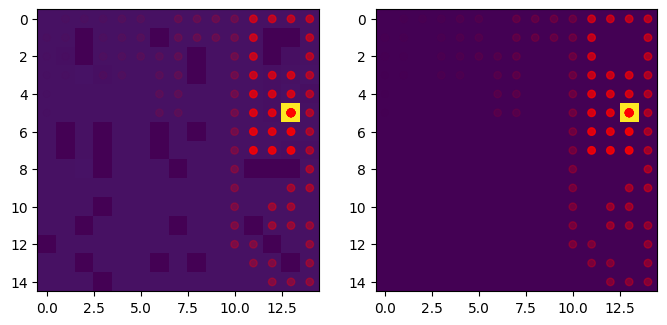

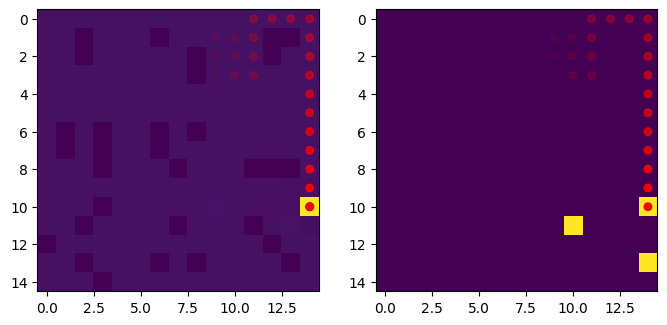

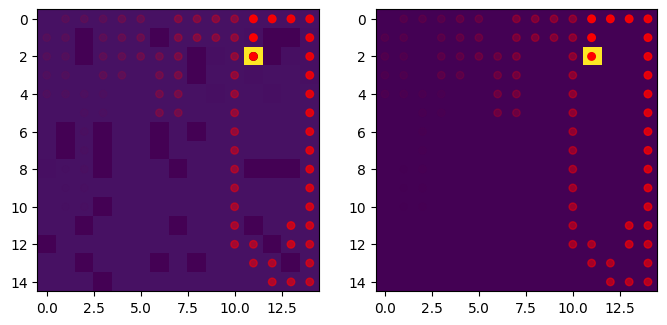

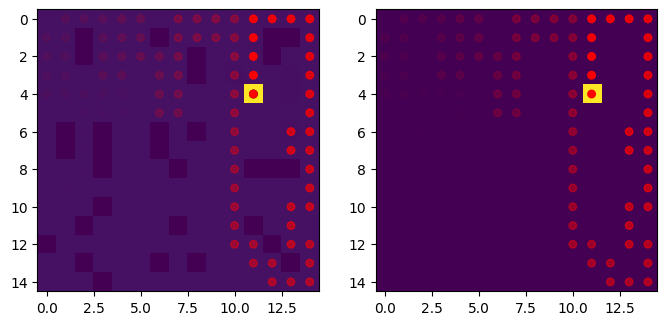

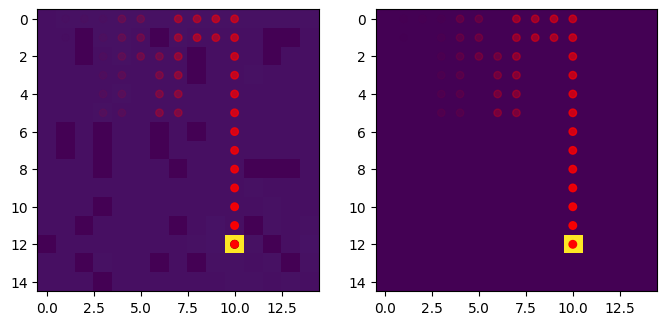

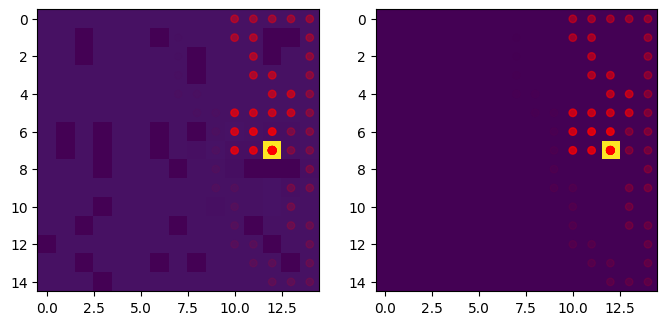

9        -9.208369e+01  -9.207992e+01


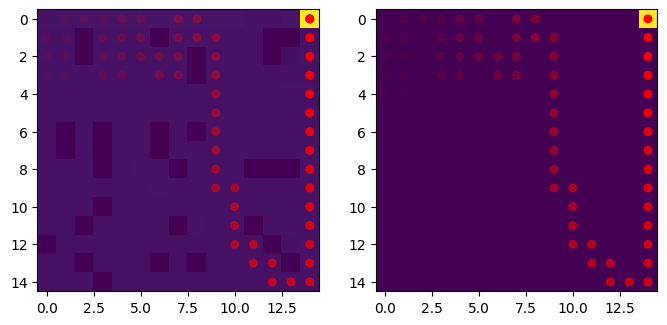

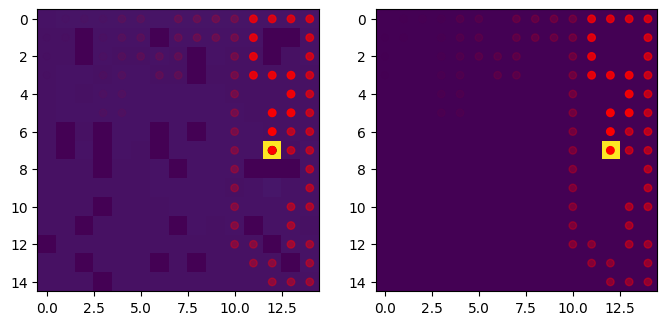

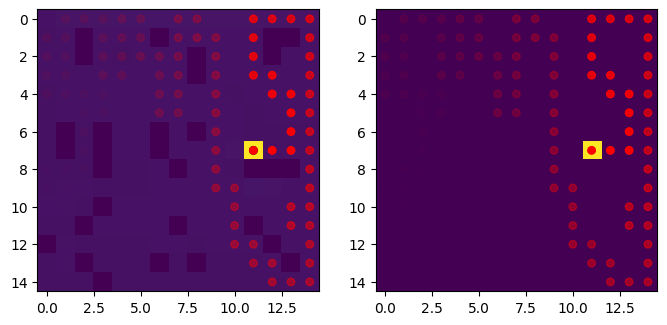

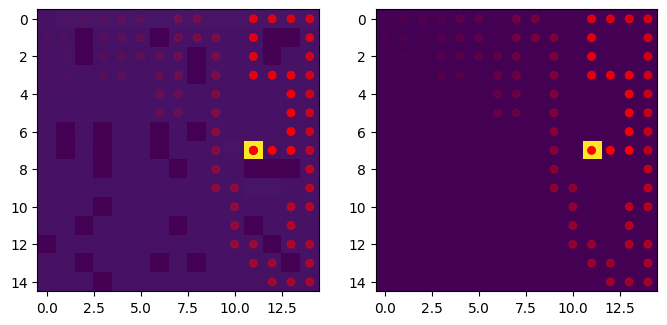

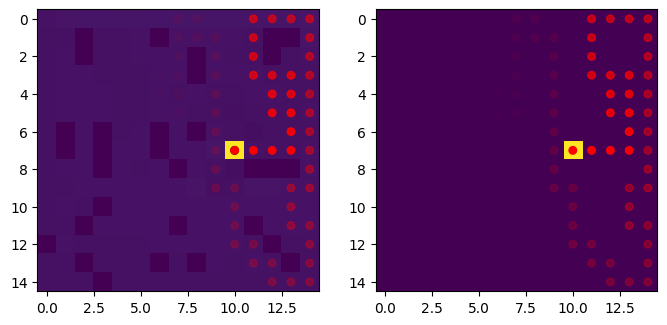

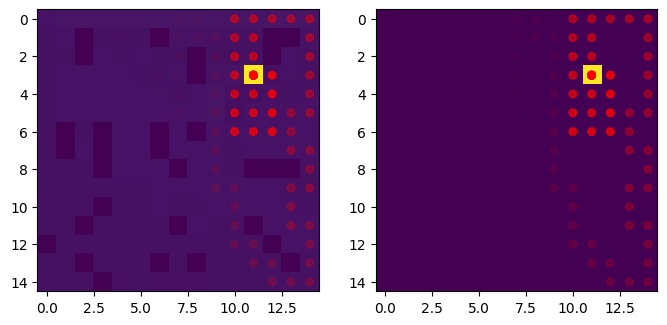

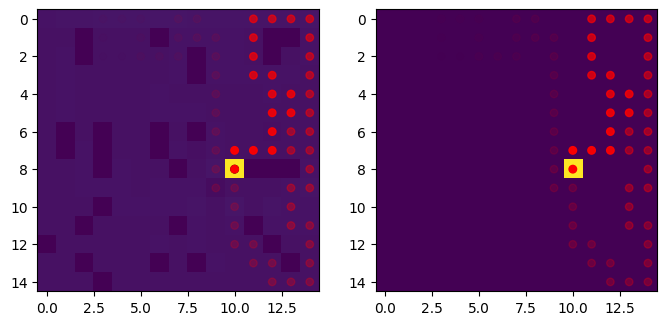

10       -9.356117e+01  -9.355886e+01


In [377]:
model, loss_dict = train_model(
    train_data = train_data,
    test_data = test_data,
    # Expected shape is (1, len(Tile), 15, 15)
    board_torch = torch.tensor(board).float(),
    model = UNet(32, bias=True),
    loss_fn = nn.NLLLoss(),
    epochs=10,
    lr=1e-3,
    print_every=1,
    visualize_images=5,
    batch_size=32
)


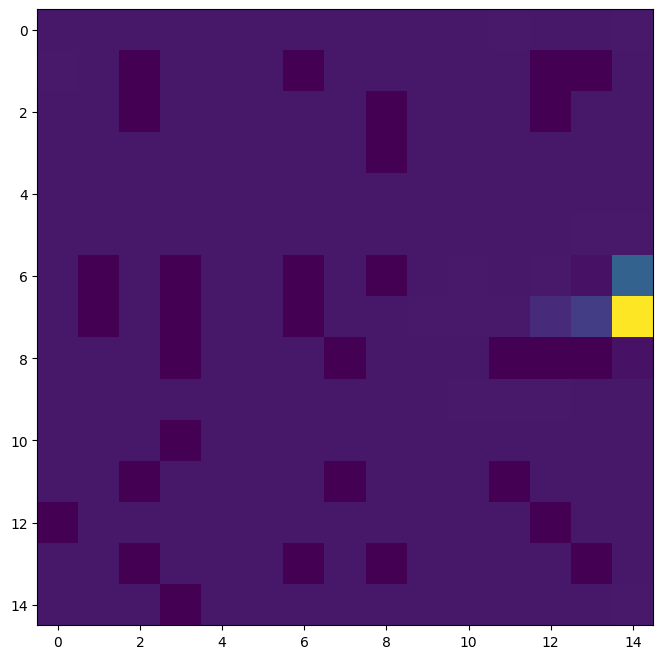

In [ ]:
empty_board = np.array([   
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]
        ])

empty_board_masked = torch.tensor(standardize_masks(np.array([empty_board]).reshape(1, 15, 15)))
output = model(empty_board_masked.unsqueeze(0), torch.tensor(board).float().unsqueeze(0).unsqueeze(0))
fig, ax = plt.subplots(1, 1, figsize = (8, 8))
ax.imshow(output.cpu().detach().numpy().squeeze().reshape(15, 15))


In [ ]:
masks[0]

array([[1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0., 0.],
       [1., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0.